### Step : 0 
### Data Collection
- Data souce :- https://www.kaggle.com/datasets/rashikrahmanpritom/data-science-job-posting-on-glassdoor?resource=download&select=Cleaned_DS_Jobs.csv 

### Import Required Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

### Step : 1 Import Required Python Library / Load Dataset¶

### Import

In [3]:
df = pd.read_csv('Data/Uncleaned_DS_jobs.csv')

In [4]:
df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),-1
2,2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),-1
3,3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"


### Step :- 2 Basic Information

#### i) Columns names

In [5]:
df.columns

Index(['index', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')

#### ii) Check duplicate rows

In [6]:
df.duplicated().sum()

0

#### iii) Check Numbers of Rows and Columns

In [7]:
print(f"Number of Rows    :- {df.shape[0]}")
print(f"Number of Columns :- {df.shape[1]}")

Number of Rows    :- 672
Number of Columns :- 15


#### iv) Check for Null values

In [8]:
df.isnull().sum().sum()

0

#### v) Check Data-Types of Columns

In [9]:
df.dtypes

index                  int64
Job Title             object
Salary Estimate       object
Job Description       object
Rating               float64
Company Name          object
Location              object
Headquarters          object
Size                  object
Founded                int64
Type of ownership     object
Industry              object
Sector                object
Revenue               object
Competitors           object
dtype: object

#### vi) Overall Information

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              672 non-null    int64  
 1   Job Title          672 non-null    object 
 2   Salary Estimate    672 non-null    object 
 3   Job Description    672 non-null    object 
 4   Rating             672 non-null    float64
 5   Company Name       672 non-null    object 
 6   Location           672 non-null    object 
 7   Headquarters       672 non-null    object 
 8   Size               672 non-null    object 
 9   Founded            672 non-null    int64  
 10  Type of ownership  672 non-null    object 
 11  Industry           672 non-null    object 
 12  Sector             672 non-null    object 
 13  Revenue            672 non-null    object 
 14  Competitors        672 non-null    object 
dtypes: float64(1), int64(2), object(12)
memory usage: 78.9+ KB


### vi). Column separation in Numerical and Category columns

In [11]:
df_num = df.select_dtypes('number')
df_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   index    672 non-null    int64  
 1   Rating   672 non-null    float64
 2   Founded  672 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 15.9 KB


In [12]:
df_cat = df.select_dtypes('object')
df_cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Job Title          672 non-null    object
 1   Salary Estimate    672 non-null    object
 2   Job Description    672 non-null    object
 3   Company Name       672 non-null    object
 4   Location           672 non-null    object
 5   Headquarters       672 non-null    object
 6   Size               672 non-null    object
 7   Type of ownership  672 non-null    object
 8   Industry           672 non-null    object
 9   Sector             672 non-null    object
 10  Revenue            672 non-null    object
 11  Competitors        672 non-null    object
dtypes: object(12)
memory usage: 63.1+ KB


### Summary
- This DataSet contain `672 Rows` and `15 columns`

#### Columns : 15
#####  Numerical Columns  : 3
    - Index   : Number of Index
    - Rating  : Rating of that post
    - Founded : Year of Founded 
##### Categorical Columns : 12
    - Job Title        : Title of the job posting
    - Salary Estimation: Salary range for that particular job
    - Job Description  : This contains the full description of that job
    - Company          : Name of company
    - Location         : Location of the company
    - Headquarter      : Location of the headquater
    - Size             : Total employee in that company
    - Type of ownership: Describes the company type i.e non-profit/public/private farm etc
    - Industry         : Field applicant will work in
    - Sector           : Field applicant will work in
    - Revenue          : Total revenue of the company
    - Competitors      : Name of Competitors 

- This Datasets not contain `Duplicate Values`
- We have missing values that can be observed as -1.

### Step :- 3 Data Preprocessing

In [13]:
df.columns

Index(['index', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')

#### i).  Droping Unwanted Column
#### ii). Replacing -1 to Null Values

In [14]:
df.drop('index',axis=1,inplace=True)

In [15]:
df.replace(-1,np.nan,inplace=True)
df.replace('-1',np.nan,inplace=True)

In [16]:
df.isna().sum()

Job Title              0
Salary Estimate        0
Job Description        0
Rating                50
Company Name           0
Location               0
Headquarters          31
Size                  27
Founded              118
Type of ownership     27
Industry              71
Sector                71
Revenue               27
Competitors          501
dtype: int64

In [17]:
df

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors
0,Sr Data Scientist,$137K-$171K (Glassdoor est.),Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna"
1,Data Scientist,$137K-$171K (Glassdoor est.),"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),NaN
2,Data Scientist,$137K-$171K (Glassdoor est.),Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),NaN
3,Data Scientist,$137K-$171K (Glassdoor est.),JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech..."
4,Data Scientist,$137K-$171K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,$105K-$167K (Glassdoor est.),Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,NaN
668,Data Scientist,$105K-$167K (Glassdoor est.),Job Description\nBecome a thought leader withi...,NaN,JKGT,"San Francisco, CA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
669,Data Scientist,$105K-$167K (Glassdoor est.),Join a thriving company that is changing the w...,NaN,AccessHope,"Irwindale, CA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
670,Data Scientist,$105K-$167K (Glassdoor est.),100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,NaN,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),NaN


In [18]:
Columns = []
for i in df.columns:
    Columns.append(i.replace(" ","_"))


In [19]:
df.columns = Columns

In [20]:
df.columns

Index(['Job_Title', 'Salary_Estimate', 'Job_Description', 'Rating',
       'Company_Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type_of_ownership', 'Industry', 'Sector', 'Revenue', 'Competitors'],
      dtype='object')

### Working On Salary Estimate Column

In [21]:
df['Salary_Estimate'].value_counts()

Salary_Estimate
$79K-$131K (Glassdoor est.)     32
$99K-$132K (Glassdoor est.)     32
$75K-$131K (Glassdoor est.)     32
$137K-$171K (Glassdoor est.)    30
$90K-$109K (Glassdoor est.)     30
$56K-$97K (Glassdoor est.)      22
$79K-$106K (Glassdoor est.)     22
$90K-$124K (Glassdoor est.)     22
$110K-$163K (Glassdoor est.)    21
$92K-$155K (Glassdoor est.)     21
$138K-$158K (Glassdoor est.)    21
$128K-$201K (Glassdoor est.)    21
$212K-$331K (Glassdoor est.)    21
$95K-$119K (Glassdoor est.)     21
$69K-$116K (Glassdoor est.)     21
$124K-$198K (Glassdoor est.)    21
$112K-$116K (Glassdoor est.)    21
$122K-$146K (Glassdoor est.)    21
$91K-$150K (Glassdoor est.)     21
$101K-$165K (Glassdoor est.)    21
$79K-$147K (Glassdoor est.)     20
$31K-$56K (Glassdoor est.)      20
$145K-$225K(Employer est.)      20
$141K-$225K (Glassdoor est.)    20
$66K-$112K (Glassdoor est.)     20
$80K-$132K (Glassdoor est.)     20
$87K-$141K (Glassdoor est.)     20
$105K-$167K (Glassdoor est.)    20
$79K

In [22]:
import re

def clean_salary(text):
    # Remove any kind of (Glassdoor est.) or (Employer est.) regardless of spacing
    text = re.sub(r'\(Glassdoor\s*est\.\)', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\(Employer\s*est\.\)', '', text, flags=re.IGNORECASE)
    
    # Remove dollar signs, 'K', and extra spaces
    text = re.sub(r'\$', '', text)
    text = re.sub(r'K', '', text, flags=re.IGNORECASE)
    text = re.sub(r'\s+', '', text)
    
    return text.strip()

In [23]:
df['Salary_Estimate'] = df['Salary_Estimate'].apply(clean_salary)

In [24]:
df['Salary_Estimate'].value_counts()

Salary_Estimate
79-131     32
99-132     32
75-131     32
137-171    30
90-109     30
56-97      22
79-106     22
90-124     22
110-163    21
92-155     21
138-158    21
128-201    21
212-331    21
95-119     21
69-116     21
124-198    21
112-116    21
122-146    21
91-150     21
101-165    21
79-147     20
31-56      20
145-225    20
141-225    20
66-112     20
80-132     20
87-141     20
105-167    20
79-133     19
71-123     19
Name: count, dtype: int64

### Cretaing Min and Max salary columns

In [25]:
df[["Min_Sal","Max_Sal"]]  = df['Salary_Estimate'].str.split("-",expand=True)

In [26]:
df.dtypes

Job_Title             object
Salary_Estimate       object
Job_Description       object
Rating               float64
Company_Name          object
Location              object
Headquarters          object
Size                  object
Founded              float64
Type_of_ownership     object
Industry              object
Sector                object
Revenue               object
Competitors           object
Min_Sal               object
Max_Sal               object
dtype: object

In [27]:
df['Min_Sal'] = df['Min_Sal'].astype('int32')
df['Max_Sal'] = df['Max_Sal'].astype('int32')

In [28]:
df['Average_Salary'] = (df['Max_Sal'] + df['Min_Sal'])/2  

In [29]:
df.columns

Index(['Job_Title', 'Salary_Estimate', 'Job_Description', 'Rating',
       'Company_Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type_of_ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Min_Sal', 'Max_Sal', 'Average_Salary'],
      dtype='object')

In [30]:
df['Average_Salary'] =  df['Average_Salary'] * 1000

In [31]:
df['Average_Salary']

0      154000.0
1      154000.0
2      154000.0
3      154000.0
4      154000.0
         ...   
667    136000.0
668    136000.0
669    136000.0
670    136000.0
671    136000.0
Name: Average_Salary, Length: 672, dtype: float64

In [32]:
df

,Job_Title,Salary_Estimate,Job_Description,Rating,Company_Name,Location,Headquarters,Size,Founded,Type_of_ownership,Industry,Sector,Revenue,Competitors,Min_Sal,Max_Sal,Average_Salary
0,Sr Data Scientist,137-171,Description\n\nThe Senior Data Scientist is re...,3.1,Healthfirst\n3.1,"New York, NY","New York, NY",1001 to 5000 employees,1993.0,Nonprofit Organization,Insurance Carriers,Insurance,Unknown / Non-Applicable,"EmblemHealth, UnitedHealth Group, Aetna",137,171,154000.0
1,Data Scientist,137-171,"Secure our Nation, Ignite your Future\n\nJoin ...",4.2,ManTech\n4.2,"Chantilly, VA","Herndon, VA",5001 to 10000 employees,1968.0,Company - Public,Research & Development,Business Services,$1 to $2 billion (USD),NaN,137,171,154000.0
2,Data Scientist,137-171,Overview\n\n\nAnalysis Group is one of the lar...,3.8,Analysis Group\n3.8,"Boston, MA","Boston, MA",1001 to 5000 employees,1981.0,Private Practice / Firm,Consulting,Business Services,$100 to $500 million (USD),NaN,137,171,154000.0
3,Data Scientist,137-171,JOB DESCRIPTION:\n\nDo you have a passion for ...,3.5,INFICON\n3.5,"Newton, MA","Bad Ragaz, Switzerland",501 to 1000 employees,2000.0,Company - Public,Electrical & Electronic Manufacturing,Manufacturing,$100 to $500 million (USD),"MKS Instruments, Pfeiffer Vacuum, Agilent Tech...",137,171,154000.0
4,Data Scientist,137-171,Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 to 200 employees,1998.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,"Commerce Signals, Cardlytics, Yodlee",137,171,154000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
667,Data Scientist,105-167,Summary\n\nWe’re looking for a data scientist ...,3.6,TRANZACT\n3.6,"Fort Lee, NJ","Fort Lee, NJ",1001 to 5000 employees,1989.0,Company - Private,Advertising & Marketing,Business Services,Unknown / Non-Applicable,NaN,105,167,136000.0
668,Data Scientist,105-167,Job Description\nBecome a thought leader withi...,NaN,JKGT,"San Francisco, CA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,105,167,136000.0
669,Data Scientist,105-167,Join a thriving company that is changing the w...,NaN,AccessHope,"Irwindale, CA",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,105,167,136000.0
670,Data Scientist,105-167,100 Remote Opportunity As an AINLP Data Scient...,5.0,ChaTeck Incorporated\n5.0,"San Francisco, CA","Santa Clara, CA",1 to 50 employees,NaN,Company - Private,Advertising & Marketing,Business Services,$1 to $5 million (USD),NaN,105,167,136000.0


In [38]:
df.isna().sum()

Job_Title              0
Salary_Estimate        0
Job_Description        0
Rating                50
Company_Name           0
Location               0
Headquarters          31
Size                  27
Founded              118
Type_of_ownership     27
Industry              71
Sector                71
Revenue               27
Competitors          501
Min_Sal                0
Max_Sal                0
Average_Salary         0
dtype: int64

### Working on Rating Column

In [42]:
df['Rating'].describe()

count    622.000000
mean       3.881833
std        0.610805
min        2.000000
25%        3.500000
50%        3.800000
75%        4.400000
max        5.000000
Name: Rating, dtype: float64

<Axes: xlabel='Rating', ylabel='Count'>

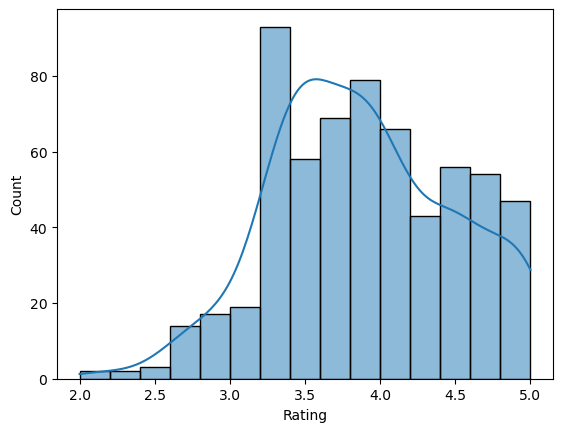

In [45]:
sns.histplot(x='Rating',data=df,kde=True)

#### Filling null values with Medium in Rating. 

In [ ]:
df['Rating']